In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -U "chronos-forecasting>=2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [51]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

from chronos import Chronos2Pipeline


DATE_COL = "date"
ID_COL = "solar_ref_id"
TARGET_COL = "solar_gen_kwh"

COVARIATE_COLS = [
    "ALLSKY_SFC_SW_DWN",
    "T2M",
    "WS2M",
    "RH2M",
    "day_of_year",
    "month",
]

CONTEXT_START = "2023-01-01"
CONTEXT_END = "2024-12-31"

TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

CONTEXT_START = pd.to_datetime(CONTEXT_START)
CONTEXT_END = pd.to_datetime(CONTEXT_END)

TEST_START = pd.to_datetime(TEST_START)
TEST_END = pd.to_datetime(TEST_END)

CONTEXT_LEN = (CONTEXT_END - CONTEXT_START).days + 1
PRED_LEN = (TEST_END - TEST_START).days + 1

print("CONTEXT_LEN:", CONTEXT_LEN)
print("PRED_LEN:", PRED_LEN)

QUANTILE_LEVELS = [0.1, 0.5, 0.9]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CONTEXT_LEN: 731
PRED_LEN: 365
Device: cuda


# **Prepare benchmark data**

In [53]:
import time
import pandas as pd
import numpy as np

full_data_path = "/content/drive/MyDrive/TT/data/main/daily/main.csv"

full_data = pd.read_csv(full_data_path, parse_dates=["date"])
full_data = full_data.drop(columns=["lat", "long", "T_cell", "temp_factor"])
full_data["date"] = pd.to_datetime(full_data["date"])

full_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
0,AUS_SOLAR_REF_000,2016-01-01,8.9544,31.15,4.20,40.78,42.557171,1,1
1,AUS_SOLAR_REF_000,2016-01-02,8.5466,26.56,4.61,53.99,41.505010,2,1
2,AUS_SOLAR_REF_000,2016-01-03,8.2236,26.15,2.78,55.57,40.121445,3,1
3,AUS_SOLAR_REF_000,2016-01-04,5.6350,25.23,3.16,58.72,28.261850,4,1
4,AUS_SOLAR_REF_000,2016-01-05,5.3940,24.70,3.66,59.91,27.166024,5,1
...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,9.6631,19.30,2.33,41.20,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,8.7079,21.64,3.20,37.60,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,9.6110,24.35,1.99,34.56,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,8.8459,27.43,1.90,27.50,42.693967,364,12


In [54]:
test_data = full_data[full_data['date'] >= "2025-01-01"]
test_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
3288,AUS_SOLAR_REF_000,2025-01-01,6.9077,33.91,2.94,28.34,33.130762,1,1
3289,AUS_SOLAR_REF_000,2025-01-02,8.4636,34.23,3.80,31.01,39.934746,2,1
3290,AUS_SOLAR_REF_000,2025-01-03,8.8351,28.54,5.57,43.08,42.465017,3,1
3291,AUS_SOLAR_REF_000,2025-01-04,9.0682,25.44,5.62,49.62,44.007231,4,1
3292,AUS_SOLAR_REF_000,2025-01-05,9.1289,27.47,4.77,43.23,43.933737,5,1
...,...,...,...,...,...,...,...,...,...
1826495,AUS_SOLAR_REF_499,2025-12-27,9.6631,19.30,2.33,41.20,47.725092,361,12
1826496,AUS_SOLAR_REF_499,2025-12-28,8.7079,21.64,3.20,37.60,43.015178,362,12
1826497,AUS_SOLAR_REF_499,2025-12-29,9.6110,24.35,1.99,34.56,46.593972,363,12
1826498,AUS_SOLAR_REF_499,2025-12-30,8.8459,27.43,1.90,27.50,42.693967,364,12


In [55]:
context_data = full_data[(full_data['date'] >= "2023-01-01") & (full_data['date'] <= "2024-12-31")]
context_data

,solar_ref_id,date,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,solar_gen_kwh,day_of_year,month
2557,AUS_SOLAR_REF_000,2023-01-01,9.1733,25.61,5.55,45.88,44.443911,1,1
2558,AUS_SOLAR_REF_000,2023-01-02,8.5126,32.21,6.23,25.99,40.464449,2,1
2559,AUS_SOLAR_REF_000,2023-01-03,8.4670,34.70,6.61,17.99,39.875917,3,1
2560,AUS_SOLAR_REF_000,2023-01-04,8.3974,35.58,5.41,15.56,39.438571,4,1
2561,AUS_SOLAR_REF_000,2023-01-05,8.5397,35.16,4.59,17.12,40.117026,5,1
...,...,...,...,...,...,...,...,...,...
1826130,AUS_SOLAR_REF_499,2024-12-27,9.0422,23.97,4.07,39.92,44.137553,362,12
1826131,AUS_SOLAR_REF_499,2024-12-28,8.9806,20.70,2.78,38.84,44.405118,363,12
1826132,AUS_SOLAR_REF_499,2024-12-29,9.2892,22.96,2.24,45.36,45.410609,364,12
1826133,AUS_SOLAR_REF_499,2024-12-30,8.7276,25.67,1.64,40.74,42.454566,365,12


In [56]:
print("context_data:", context_data.shape)
print("test_data:", test_data.shape)

context_data: (365500, 9)
test_data: (182500, 9)


In [57]:
def prepare_df(df):
    df = df.copy()

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df[ID_COL] = df[ID_COL].astype(str)

    numeric_cols = [TARGET_COL] + COVARIATE_COLS

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

    return df


def filter_by_date_range(context_data, test_data):
    context_data = context_data[
        (context_data[DATE_COL] >= CONTEXT_START) &
        (context_data[DATE_COL] <= CONTEXT_END)
    ].copy()

    test_data = test_data[
        (test_data[DATE_COL] >= TEST_START) &
        (test_data[DATE_COL] <= TEST_END)
    ].copy()

    ctx_count = context_data.groupby(ID_COL)[DATE_COL].nunique()
    test_count = test_data.groupby(ID_COL)[DATE_COL].nunique()

    coverage = pd.DataFrame({
        "context_days": ctx_count,
        "test_days": test_count,
    }).fillna(0).astype(int)

    coverage["valid"] = (
        (coverage["context_days"] == CONTEXT_LEN) &
        (coverage["test_days"] == PRED_LEN)
    )

    valid_ids = coverage[coverage["valid"]].index.tolist()

    context_data = context_data[context_data[ID_COL].isin(valid_ids)].copy()
    test_data = test_data[test_data[ID_COL].isin(valid_ids)].copy()

    return context_data, test_data, coverage, valid_ids

context_data = prepare_df(context_data)
test_data = prepare_df(test_data)

context_data, test_data, coverage, valid_ids = filter_by_date_range(
    context_data,
    test_data,
)

print("CONTEXT_LEN:", CONTEXT_LEN)
print("PRED_LEN:", PRED_LEN)
print("context_data:", context_data.shape)
print("test_data:", test_data.shape)
print("valid series:", len(valid_ids))

display(coverage.head(20))

CONTEXT_LEN: 731
PRED_LEN: 365
context_data: (365500, 9)
test_data: (182500, 9)
valid series: 500


,context_days,test_days,valid
solar_ref_id,,,
AUS_SOLAR_REF_000,731,365,True
AUS_SOLAR_REF_001,731,365,True
AUS_SOLAR_REF_002,731,365,True
AUS_SOLAR_REF_003,731,365,True
AUS_SOLAR_REF_004,731,365,True
AUS_SOLAR_REF_005,731,365,True
AUS_SOLAR_REF_006,731,365,True
AUS_SOLAR_REF_007,731,365,True
AUS_SOLAR_REF_008,731,365,True


In [58]:
def compute_rmse(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return mean_squared_error(y_true, y_pred) ** 0.5


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    ) * 100


def evaluate_forecast(pred_df, test_df, model_name, benchmark_name):
    pred_df = pred_df.copy()
    test_df = test_df.copy()

    pred_df[DATE_COL] = pd.to_datetime(pred_df[DATE_COL])
    test_df[DATE_COL] = pd.to_datetime(test_df[DATE_COL])

    pred_df[ID_COL] = pred_df[ID_COL].astype(str)
    test_df[ID_COL] = test_df[ID_COL].astype(str)

    merged = test_df[[ID_COL, DATE_COL, TARGET_COL]].merge(
        pred_df[[ID_COL, DATE_COL, "y_pred"]],
        on=[ID_COL, DATE_COL],
        how="inner",
    )

    if len(merged) == 0:
        raise ValueError(f"Không match được dòng nào cho {model_name} - {benchmark_name}")

    y_true = merged[TARGET_COL].to_numpy()
    y_pred = merged["y_pred"].to_numpy()

    metrics = {
        "model": model_name,
        "benchmark": benchmark_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": compute_rmse(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "sMAPE": smape(y_true, y_pred),
        "n_points": len(merged),
        "n_series": merged[ID_COL].nunique(),
    }

    return metrics, merged

In [59]:
def normalize_chronos_output(pred_df):
    pred_df = pred_df.copy()

    rename_map = {}

    for col in pred_df.columns:
        col_str = str(col)

        if col_str in ["0.1", "q0.1", "p10", "P10"]:
            rename_map[col] = "q0.1"
        elif col_str in ["0.5", "q0.5", "median", "p50", "P50"]:
            rename_map[col] = "q0.5"
        elif col_str in ["0.9", "q0.9", "p90", "P90"]:
            rename_map[col] = "q0.9"
        elif col_str in ["mean", "prediction", "forecast"]:
            rename_map[col] = "mean"

    pred_df = pred_df.rename(columns=rename_map)

    if "q0.5" in pred_df.columns:
        pred_df["y_pred"] = pred_df["q0.5"]
    elif "mean" in pred_df.columns:
        pred_df["y_pred"] = pred_df["mean"]
    elif "y_pred" in pred_df.columns:
        pass
    else:
        raise ValueError(f"Không tìm thấy cột dự báo. Columns: {pred_df.columns.tolist()}")

    keep_cols = [ID_COL, DATE_COL, "y_pred"]

    for qcol in ["q0.1", "q0.5", "q0.9"]:
        if qcol in pred_df.columns:
            keep_cols.append(qcol)

    pred_df = pred_df[keep_cols].copy()

    pred_df[DATE_COL] = pd.to_datetime(pred_df[DATE_COL])
    pred_df[ID_COL] = pred_df[ID_COL].astype(str)

    return pred_df

# **Load model and predict**

In [60]:
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=DEVICE,
)

print("Chronos-2 loaded")

Chronos-2 loaded


In [61]:
def run_chronos2_target_only(context_data):
    start = time.time()

    context_input = context_data[
        [ID_COL, DATE_COL, TARGET_COL]
    ].copy()

    pred_df = pipeline.predict_df(
        context_input,
        prediction_length=PRED_LEN,
        quantile_levels=QUANTILE_LEVELS,
        id_column=ID_COL,
        timestamp_column=DATE_COL,
        target=TARGET_COL,
    )

    pred_df = normalize_chronos_output(pred_df)

    runtime = time.time() - start

    return pred_df, runtime


chronos_target_pred, chronos_target_runtime = run_chronos2_target_only(
    context_data
)

chronos_target_metrics, chronos_target_merged = evaluate_forecast(
    pred_df=chronos_target_pred,
    test_df=test_data,
    model_name="Chronos-2",
    benchmark_name="target_only",
)

chronos_target_metrics["runtime_seconds"] = chronos_target_runtime

display(chronos_target_pred.head())
chronos_target_metrics

,solar_ref_id,date,y_pred,q0.1,q0.5,q0.9
0,AUS_SOLAR_REF_000,2025-01-01,36.520107,28.219307,36.520107,41.085800
1,AUS_SOLAR_REF_000,2025-01-02,40.872520,30.392670,40.872520,44.092552
2,AUS_SOLAR_REF_000,2025-01-03,41.939125,32.415253,41.939125,44.250904
3,AUS_SOLAR_REF_000,2025-01-04,42.309052,33.280724,42.309052,44.360817
4,AUS_SOLAR_REF_000,2025-01-05,42.397003,33.062756,42.397003,44.358280


{'model': 'Chronos-2',
 'benchmark': 'target_only',
 'MAE': 4.253509041271658,
 'RMSE': 6.14751625003269,
 'MSE': 37.79195604441598,
 'MAPE': 23.674799548278923,
 'sMAPE': np.float64(17.841159479061503),
 'n_points': 182500,
 'n_series': 500,
 'runtime_seconds': 3.4211983680725098}

In [62]:
def run_chronos2_target_future_covariates(context_data, test_data):
    start = time.time()

    context_input = context_data[
        [ID_COL, DATE_COL, TARGET_COL] + COVARIATE_COLS
    ].copy()

    future_df = test_data[
        [ID_COL, DATE_COL] + COVARIATE_COLS
    ].copy()

    pred_df = pipeline.predict_df(
        context_input,
        future_df=future_df,
        prediction_length=PRED_LEN,
        quantile_levels=QUANTILE_LEVELS,
        id_column=ID_COL,
        timestamp_column=DATE_COL,
        target=TARGET_COL,
    )

    pred_df = normalize_chronos_output(pred_df)

    runtime = time.time() - start

    return pred_df, runtime


chronos_cov_pred, chronos_cov_runtime = run_chronos2_target_future_covariates(
    context_data,
    test_data,
)

chronos_cov_metrics, chronos_cov_merged = evaluate_forecast(
    pred_df=chronos_cov_pred,
    test_df=test_data,
    model_name="Chronos-2",
    benchmark_name="target_future_covariates",
)

chronos_cov_metrics["runtime_seconds"] = chronos_cov_runtime

display(chronos_cov_pred.head())
chronos_cov_metrics

,solar_ref_id,date,y_pred,q0.1,q0.5,q0.9
0,AUS_SOLAR_REF_000,2025-01-01,34.157345,32.733578,34.157345,35.432636
1,AUS_SOLAR_REF_000,2025-01-02,42.074291,40.834641,42.074291,43.048515
2,AUS_SOLAR_REF_000,2025-01-03,43.832130,42.810783,43.832130,44.600231
3,AUS_SOLAR_REF_000,2025-01-04,44.223927,43.452240,44.223927,45.085938
4,AUS_SOLAR_REF_000,2025-01-05,44.538166,43.718628,44.538166,45.467361


{'model': 'Chronos-2',
 'benchmark': 'target_future_covariates',
 'MAE': 0.6017726192694975,
 'RMSE': 0.7603440444833933,
 'MSE': 0.5781230659813644,
 'MAPE': 2.7503929916620384,
 'sMAPE': np.float64(2.751646571482955),
 'n_points': 182500,
 'n_series': 500,
 'runtime_seconds': 21.970497369766235}

# **Benchmark**

In [64]:
chronos_target_pred.to_csv("/content/drive/MyDrive/TT/benchmark_results/chronos_target_only_pred.csv", index=False)
chronos_cov_pred.to_csv("/content/drive/MyDrive/TT/benchmark_results/chronos_future_cov_pred.csv", index=False)

chronos_metrics = pd.DataFrame([
    chronos_target_metrics,
    chronos_cov_metrics,
])

display(chronos_metrics)

chronos_metrics.to_csv("/content/drive/MyDrive/TT/benchmark_results/chronos_metrics.csv", index=False)

print("Saved:")
print("- chronos_target_only_pred.csv")
print("- chronos_future_cov_pred.csv")
print("- chronos_metrics.csv")

,model,benchmark,MAE,RMSE,MSE,MAPE,sMAPE,n_points,n_series,runtime_seconds
0,Chronos-2,target_only,4.253509,6.147516,37.791956,23.674800,17.841159,182500,500,3.421198
1,Chronos-2,target_future_covariates,0.601773,0.760344,0.578123,2.750393,2.751647,182500,500,21.970497


Saved:
- chronos_target_only_pred.csv
- chronos_future_cov_pred.csv
- chronos_metrics.csv


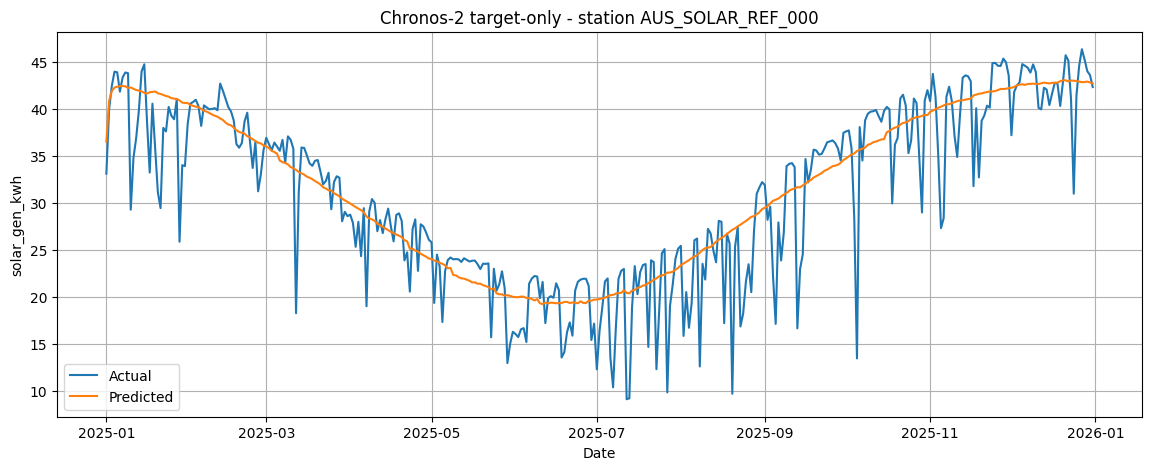

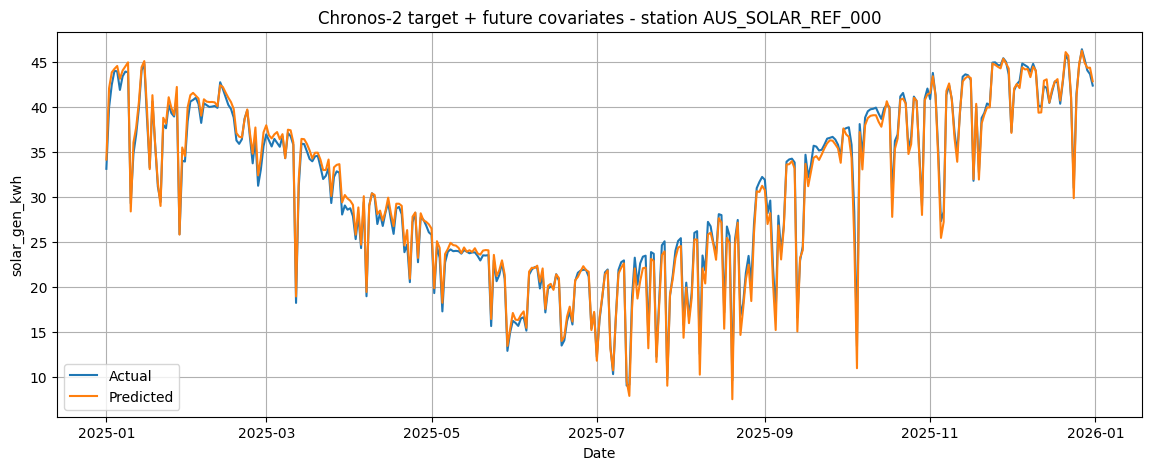

In [66]:
import matplotlib.pyplot as plt

def plot_forecast_for_station(pred_df, test_df, station_id, title):
    station_id = str(station_id)

    pred_g = pred_df[pred_df[ID_COL] == station_id].sort_values(DATE_COL)
    test_g = test_df[test_df[ID_COL] == station_id].sort_values(DATE_COL)

    merged = test_g[[DATE_COL, TARGET_COL]].merge(
        pred_g[[DATE_COL, "y_pred"]],
        on=DATE_COL,
        how="inner",
    )

    plt.figure(figsize=(14, 5))
    plt.plot(merged[DATE_COL], merged[TARGET_COL], label="Actual")
    plt.plot(merged[DATE_COL], merged["y_pred"], label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.grid(True)
    plt.show()


sample_station = valid_ids[0]

plot_forecast_for_station(
    pred_df=chronos_target_pred,
    test_df=test_data,
    station_id=sample_station,
    title=f"Chronos-2 target-only - station {sample_station}",
)

plot_forecast_for_station(
    pred_df=chronos_cov_pred,
    test_df=test_data,
    station_id=sample_station,
    title=f"Chronos-2 target + future covariates - station {sample_station}",
)